#### environment

In [1]:
import os 
import numpy as np
from numpy import full
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import MultipleLocator
from predict_loop_functions import predict_loop, noise_iterations, add_brain_region
from scipy.stats import linregress

In [2]:
# use image stack from july16 already saved
image_stack = np.load('saved_inputs_outputs//image_stack_july16.npy')

In [3]:
neurons = np.array([1685,368,1571,670,1918,1231,6795,6492,2507,1444,2361,6699,6672,6790,6209,6699,
           1447,5583,2237,2161,7217,5114,4321,4823,6822,5935,823,6501,6819,5782])

#### testing

In [3]:
test1, test2, test3 = predict_loop('dynamic', image_stack, 3, [[4,7]], noise_seeds = 3, num_frames = 1)

In [4]:
test4, test5, test6 = predict_loop('constant', image_stack, 25, [[4,7]], noise_seeds = 3, num_frames = 1)

#### predictions

In [3]:
d3_sum, d3_mean, d3_var = predict_loop('dynamic', image_stack, 3, [[4,7]])

In [4]:
d15_sum, d15_mean, d15_var = predict_loop('dynamic', image_stack, 15, [[4,7]])

In [5]:
d30_sum, d30_mean, d30_var = predict_loop('dynamic', image_stack, 30, [[4,7]])

In [ ]:
c3_sum, c3_mean, c3_var = predict_loop('constant', image_stack, 3, [[4,7]])

In [7]:
c15_sum, c15_mean, c15_var = predict_loop('constant', image_stack, 15, [[4,7]])

In [8]:
c30_sum, c30_mean, c30_var = predict_loop('constant', image_stack, 30, [[4,7]])

In [10]:
dbin_sum, dbin_mean, dbin_var = predict_loop('dynamic', image_stack, 0, [[4,7]], stochastic_bin_param = True)

In [9]:
cbin_sum, cbin_mean, cbin_var = predict_loop('constant', image_stack, 0, [[4,7]], stochastic_bin_param = True)

saving predictions to july 18 folder in saved_inputs_outputs

In [20]:
for noise in ['c3', 'c15', 'c30', 'd3', 'd15', 'd30']:
    for type in ['_sum', '_mean', '_var']:
        file_name = noise + type
        path = 'saved_inputs_outputs//predictions_july18//' + file_name
        np.save(path, arr = globals()[file_name])

In [21]:
for noise in ['dbin', 'cbin']:
    for func in ['_sum', '_mean', '_var']:
        file_name = noise + func
        path = 'saved_inputs_outputs//predictions_july18//' + file_name
        np.save(path, arr = globals()[file_name])

#### load predictions from folder

In [9]:
for noise in ['c3', 'c15', 'c30', 'd3', 'd15', 'd30']:
    for type in ['_sum', '_mean', '_var']:
        file_name = noise + type + '.npy'
        var_name = noise + type
        path = 'saved_inputs_outputs//predictions_july18//' + file_name
        globals()[var_name] = np.load(path)

In [5]:
dbin_sum = np.load('saved_inputs_outputs//predictions_july18//dbin_sum.npy')
dbin_mean = np.load('saved_inputs_outputs//predictions_july18//dbin_mean.npy')
dbin_var = np.load('saved_inputs_outputs//predictions_july18//dbin_var.npy')

In [6]:
cbin_sum = np.load('saved_inputs_outputs//predictions_july18//cbin_sum.npy')
cbin_mean = np.load('saved_inputs_outputs//predictions_july18//cbin_mean.npy')
cbin_var = np.load('saved_inputs_outputs//predictions_july18//cbin_var.npy')

#### sigma against mean

In [10]:
def line_plot_mean(array, neurons):
    array = array[:,:,:,0]
    final_array = np.empty(shape = len(neurons))
    for i, neuron in enumerate(neurons):
        avg = np.mean(np.sum(array[:,:,neuron], axis = 1))
        final_array[i] = avg
    return final_array

In [11]:
mean_d30 = line_plot_mean(d30_sum, [i for i in range(100)])
mean_d15 = line_plot_mean(d15_sum, [i for i in range(100)])
mean_d3 = line_plot_mean(d3_sum, [i for i in range(100)])
mean_c30 = line_plot_mean(c30_sum, [i for i in range(100)])
mean_c15 = line_plot_mean(c15_sum, [i for i in range(100)])
mean_c3 = line_plot_mean(c3_sum, [i for i in range(100)])

In [12]:
mean_c15.shape

(100,)

In [13]:
min(mean_c15)

np.float64(110.1896889977157)

In [14]:
np.mean(mean_d30)

np.float64(930.0802940013567)

C:\Users\joshf\AppData\Local\Temp\ipykernel_56848\2078862445.py:29: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)
C:\Users\joshf\AppData\Local\Temp\ipykernel_56848\2078862445.py:32: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)


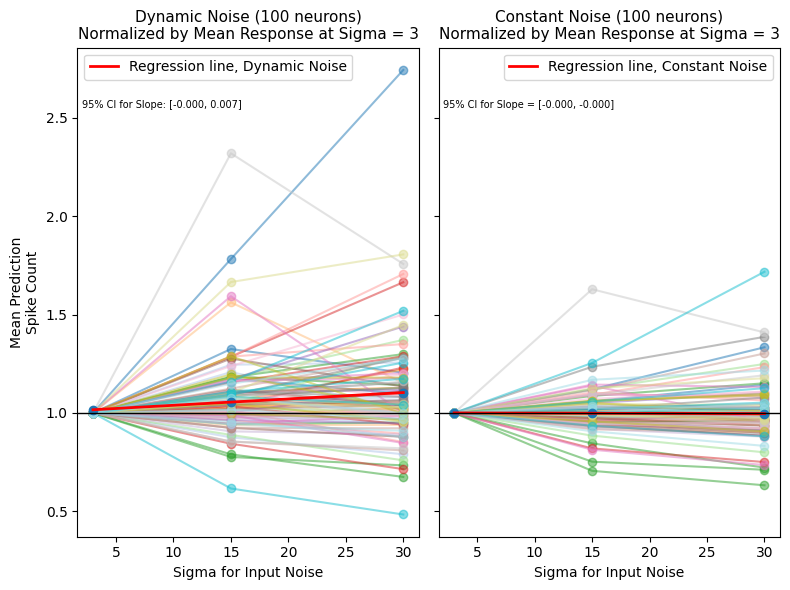

In [29]:
fig, axes = plt.subplots(1,2, figsize = (8,6), sharey = True)

sigmas = np.array([3, 15, 30])

dynamic_means = [mean_d3, mean_d15, mean_d30] 
constant_means = [mean_c3, mean_c15, mean_c30] 

colors = plt.cm.tab20(np.linspace(0, 1, 100))  # 100 colors for 100 neurons

for i in range(100):
    constant_y = [mean_c3[i], mean_c15[i], mean_c30[i]] / mean_c3[i]
    dynamic_y = [mean_d3[i], mean_d15[i], mean_d30[i]] / mean_d3[i]

    axes[0].plot(sigmas, dynamic_y, marker='o', linestyle='-', alpha=0.5, color = colors[i])

    axes[1].plot(sigmas, constant_y, marker='o', linestyle='-', alpha=0.5, color = colors[i])
    
dynamic_mean_y = np.mean(dynamic_means, axis=1) / np.mean(mean_d3)  
constant_mean_y = np.mean(constant_means, axis=1) / np.mean(mean_c3)

slope_dyn, intercept_dyn, r_value_dyn, p_value_dyn, std_err_dyn = linregress(sigmas, dynamic_mean_y)
y_pred_dyn = intercept_dyn + slope_dyn * sigmas

slope_con, intercept_con, r_value_con, p_value_con, std_err_con = linregress(sigmas, constant_mean_y)
y_pred_con = intercept_con + slope_con * sigmas


axes[0].plot(sigmas, y_pred_dyn, 'o')
axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)

axes[1].plot(sigmas, y_pred_con, 'o')
axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)

# error band/SE
dyn_se = std_err_dyn * np.sqrt(1/len(sigmas) + (sigmas - np.mean(sigmas))**2 / np.sum((sigmas - np.mean(sigmas))**2))
con_se = std_err_con * np.sqrt(1/len(sigmas) + (sigmas - np.mean(sigmas))**2 / np.sum((sigmas - np.mean(sigmas))**2))
axes[0].fill_between(sigmas, y_pred_dyn - 1.96*dyn_se, y_pred_dyn + 1.96*dyn_se, color='red',  alpha = 0.3)
axes[1].fill_between(sigmas, y_pred_con - 1.96*con_se, y_pred_con + 1.96*con_se, color='red', alpha = 0.3)

axes[0].text(2, 2.55, f'95% CI for Slope: [{slope_dyn - 1.96 * std_err_dyn:.3f}, {slope_dyn + 1.96 * std_err_dyn:.3f}]', fontsize = 7) # x1.96 for 95% CI
axes[1].text(2, 2.55, f'95% CI for Slope = [{slope_con - 1.96 * std_err_con:.3f}, {slope_con + 1.96 * std_err_con:.3f}]', fontsize = 7)

axes[0].axhline(y=1, color='black', linestyle='-', linewidth=1)
axes[1].axhline(y=1, color='black', linestyle='-', linewidth=1)
axes[0].set_xlabel('Sigma for Input Noise')
axes[0].set_title('Dynamic Noise (100 neurons)\nNormalized by Mean Response at Sigma = 3', fontsize = 11)
axes[1].set_title('Constant Noise (100 neurons)\nNormalized by Mean Response at Sigma = 3', fontsize = 11)
axes[0].set_ylabel('Mean Prediction\nSpike Count')
axes[1].set_xlabel('Sigma for Input Noise')
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()

C:\Users\joshf\AppData\Local\Temp\ipykernel_15408\2992686199.py:28: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)
C:\Users\joshf\AppData\Local\Temp\ipykernel_15408\2992686199.py:31: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)


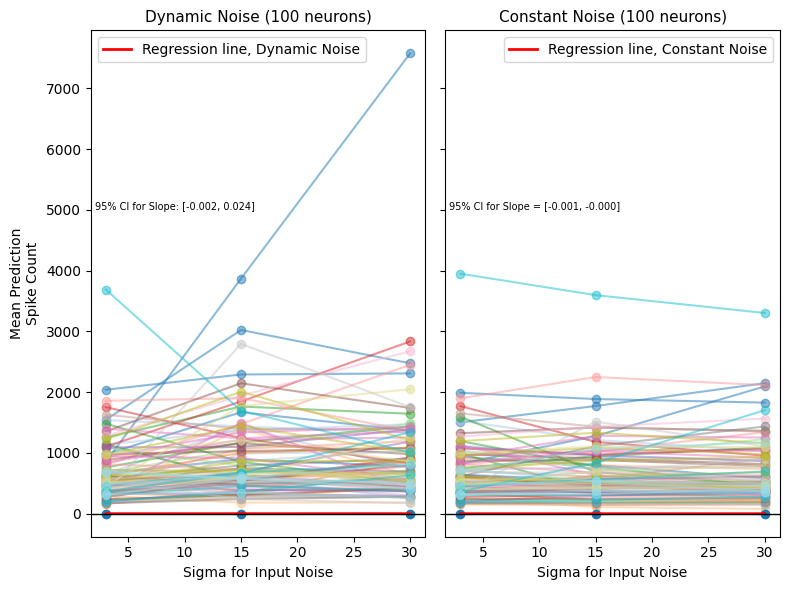

In [15]:
fig, axes = plt.subplots(1,2, figsize = (8,6), sharey = True)

sigmas = np.array([3, 15, 30])

dynamic_means = [mean_d3, mean_d15, mean_d30] 
constant_means = [mean_c3, mean_c15, mean_c30] 

colors = plt.cm.tab20(np.linspace(0, 1, 100))  # 100 colors for 100 neurons

for i in range(100):
    constant_y = [mean_c3[i], mean_c15[i], mean_c30[i]] 
    dynamic_y = [mean_d3[i], mean_d15[i], mean_d30[i]] 
    axes[0].plot(sigmas, dynamic_y, marker='o', linestyle='-', alpha=0.5, color = colors[i])

    axes[1].plot(sigmas, constant_y, marker='o', linestyle='-', alpha=0.5, color = colors[i])
    
dynamic_mean_y = np.mean(dynamic_means, axis=1) / np.mean(mean_d3)  
constant_mean_y = np.mean(constant_means, axis=1) / np.mean(mean_c3)

slope_dyn, intercept_dyn, r_value_dyn, p_value_dyn, std_err_dyn = linregress(sigmas, dynamic_mean_y)
y_pred_dyn = intercept_dyn + slope_dyn * sigmas

slope_con, intercept_con, r_value_con, p_value_con, std_err_con = linregress(sigmas, constant_mean_y)
y_pred_con = intercept_con + slope_con * sigmas


axes[0].plot(sigmas, y_pred_dyn, 'o')
axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)

axes[1].plot(sigmas, y_pred_con, 'o')
axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)

# error band/SE
dyn_se = std_err_dyn * np.sqrt(1/len(sigmas) + (sigmas - np.mean(sigmas))**2 / np.sum((sigmas - np.mean(sigmas))**2))
con_se = std_err_con * np.sqrt(1/len(sigmas) + (sigmas - np.mean(sigmas))**2 / np.sum((sigmas - np.mean(sigmas))**2))
axes[0].fill_between(sigmas, y_pred_dyn - 1.96*dyn_se, y_pred_dyn + 1.96*dyn_se, color='red',  alpha = 0.3)
axes[1].fill_between(sigmas, y_pred_con - 1.96*con_se, y_pred_con + 1.96*con_se, color='red', alpha = 0.3)

axes[0].text(2, 5000, f'95% CI for Slope: [{slope_dyn - 1.96 * std_err_dyn:.3f}, {slope_dyn + 1.96 * std_err_dyn:.3f}]', fontsize = 7) # x1.96 for 95% CI
axes[1].text(2, 5000, f'95% CI for Slope = [{slope_con - 1.96 * std_err_con:.3f}, {slope_con + 1.96 * std_err_con:.3f}]', fontsize = 7)

axes[0].axhline(y=1, color='black', linestyle='-', linewidth=1)
axes[1].axhline(y=1, color='black', linestyle='-', linewidth=1)
axes[0].set_xlabel('Sigma for Input Noise')
axes[0].set_title('Dynamic Noise (100 neurons)', fontsize = 11)
axes[1].set_title('Constant Noise (100 neurons)', fontsize = 11)
axes[0].set_ylabel('Mean Prediction\nSpike Count')
axes[1].set_xlabel('Sigma for Input Noise')
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()

#### sigma against variance

In [31]:
def line_plot_var(array, neurons):
    array = array[:,:,:]
    final_array = np.empty(shape = len(neurons))
    for i, neuron in enumerate(neurons):
        avg = np.var(np.sum(array[:,:,neuron], axis = 1))
        final_array[i] = avg
    return final_array

In [32]:
d30var = line_plot_var(d30_sum, [i for i in range(100)])
d15var = line_plot_var(d15_sum, [i for i in range(100)])
d3var = line_plot_var(d3_sum, [i for i in range(100)])
c30var = line_plot_var(c30_sum, [i for i in range(100)])
c15var = line_plot_var(c15_sum, [i for i in range(100)])
c3var = line_plot_var(c3_sum, [i for i in range(100)])

C:\Users\joshf\AppData\Local\Temp\ipykernel_56848\3291454679.py:29: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)
C:\Users\joshf\AppData\Local\Temp\ipykernel_56848\3291454679.py:32: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)


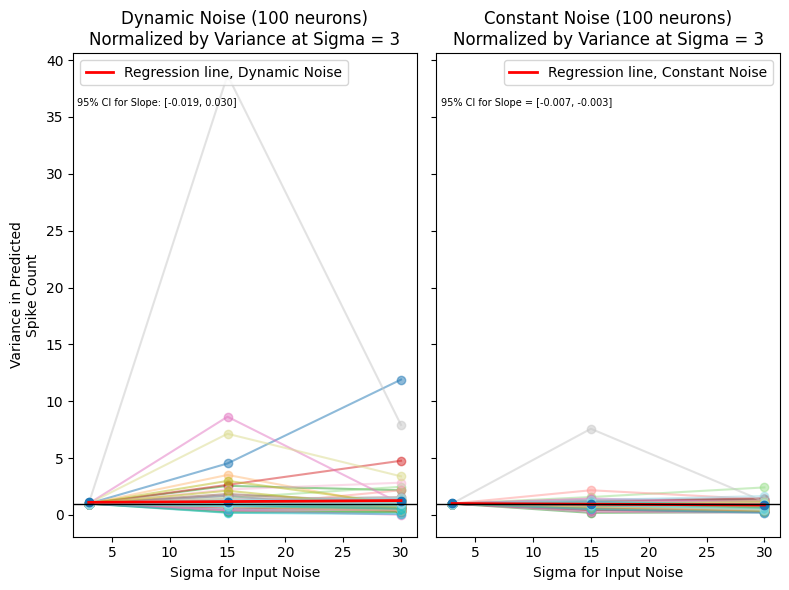

In [33]:
fig, axes = plt.subplots(1,2, figsize = (8,6), sharey = True)

sigmas = np.array([3, 15, 30])

dynamic_var = [d3var, d15var, d30var] 
constant_var = [c3var, c15var, c30var] 

colors = plt.cm.tab20(np.linspace(0, 1, 100))  # 100 colors for 100 neurons

for i in range(100):
    constant_y = [c3var[i], c15var[i], c30var[i]] / c3var[i]
    dynamic_y = [d3var[i], d15var[i], d30var[i]] / d3var[i]

    axes[0].plot(sigmas, dynamic_y, marker='o', linestyle='-', alpha=0.5, color = colors[i])

    axes[1].plot(sigmas, constant_y, marker='o', linestyle='-', alpha=0.5, color = colors[i])
    
dynamic_mean_y = np.mean(dynamic_var, axis=1) / np.mean(d3var)  
constant_mean_y = np.mean(constant_var, axis=1) / np.mean(c3var)

slope_dyn, intercept_dyn, r_value_dyn, p_value_dyn, std_err_dyn = linregress(sigmas, dynamic_mean_y)
y_pred_dyn = intercept_dyn + slope_dyn * sigmas

slope_con, intercept_con, r_value_con, p_value_con, std_err_con = linregress(sigmas, constant_mean_y)
y_pred_con = intercept_con + slope_con * sigmas


axes[0].plot(sigmas, y_pred_dyn, 'o')
axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)

axes[1].plot(sigmas, y_pred_con, 'o')
axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)

# error band/SE
dyn_se = std_err_dyn * np.sqrt(1/len(sigmas) + (sigmas - np.mean(sigmas))**2 / np.sum((sigmas - np.mean(sigmas))**2))
con_se = std_err_con * np.sqrt(1/len(sigmas) + (sigmas - np.mean(sigmas))**2 / np.sum((sigmas - np.mean(sigmas))**2))
axes[0].fill_between(sigmas, y_pred_dyn - 1.96*dyn_se, y_pred_dyn + 1.96*dyn_se, color='red',  alpha = 0.3)
axes[1].fill_between(sigmas, y_pred_con - 1.96*con_se, y_pred_con + 1.96*con_se, color='red', alpha = 0.3)

axes[0].text(2, 36, f'95% CI for Slope: [{slope_dyn - 1.96 * std_err_dyn:.3f}, {slope_dyn + 1.96 * std_err_dyn:.3f}]', fontsize = 7) # x1.96 for 95% CI
axes[1].text(2, 36, f'95% CI for Slope = [{slope_con - 1.96 * std_err_con:.3f}, {slope_con + 1.96 * std_err_con:.3f}]', fontsize = 7)

axes[0].axhline(y=1, color='black', linestyle='-', linewidth=1)
axes[1].axhline(y=1, color='black', linestyle='-', linewidth=1)
axes[0].set_xlabel('Sigma for Input Noise')
axes[0].set_title('Dynamic Noise (100 neurons)\nNormalized by Variance at Sigma = 3')
axes[1].set_title('Constant Noise (100 neurons)\nNormalized by Variance at Sigma = 3')
axes[0].set_ylabel('Variance in Predicted\nSpike Count')
axes[1].set_xlabel('Sigma for Input Noise')
axes[0].legend(loc = 'upper left')
axes[1].legend()
plt.tight_layout()
plt.show()

C:\Users\joshf\AppData\Local\Temp\ipykernel_56848\1237757635.py:29: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)
C:\Users\joshf\AppData\Local\Temp\ipykernel_56848\1237757635.py:32: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)


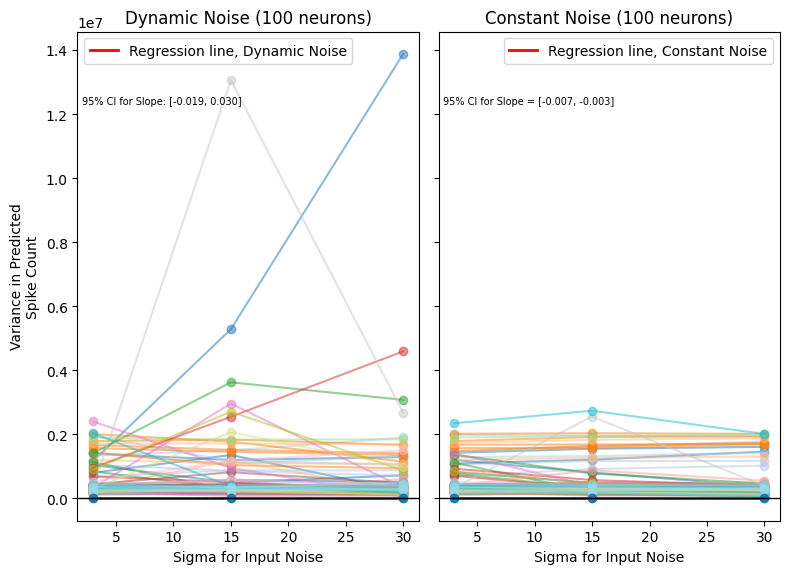

In [34]:
fig, axes = plt.subplots(1,2, figsize = (8,6), sharey = True)

sigmas = np.array([3, 15, 30])

dynamic_var = [d3var, d15var, d30var] 
constant_var = [c3var, c15var, c30var] 

colors = plt.cm.tab20(np.linspace(0, 1, 100))  # 100 colors for 100 neurons

for i in range(100):
    constant_y = [c3var[i], c15var[i], c30var[i]] 
    dynamic_y = [d3var[i], d15var[i], d30var[i]] 

    axes[0].plot(sigmas, dynamic_y, marker='o', linestyle='-', alpha=0.5, color = colors[i])

    axes[1].plot(sigmas, constant_y, marker='o', linestyle='-', alpha=0.5, color = colors[i])
    
dynamic_mean_y = np.mean(dynamic_var, axis=1) / np.mean(d3var)  
constant_mean_y = np.mean(constant_var, axis=1) / np.mean(c3var)

slope_dyn, intercept_dyn, r_value_dyn, p_value_dyn, std_err_dyn = linregress(sigmas, dynamic_mean_y)
y_pred_dyn = intercept_dyn + slope_dyn * sigmas

slope_con, intercept_con, r_value_con, p_value_con, std_err_con = linregress(sigmas, constant_mean_y)
y_pred_con = intercept_con + slope_con * sigmas


axes[0].plot(sigmas, y_pred_dyn, 'o')
axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)

axes[1].plot(sigmas, y_pred_con, 'o')
axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)

# error band/SE
dyn_se = std_err_dyn * np.sqrt(1/len(sigmas) + (sigmas - np.mean(sigmas))**2 / np.sum((sigmas - np.mean(sigmas))**2))
con_se = std_err_con * np.sqrt(1/len(sigmas) + (sigmas - np.mean(sigmas))**2 / np.sum((sigmas - np.mean(sigmas))**2))
axes[0].fill_between(sigmas, y_pred_dyn - 1.96*dyn_se, y_pred_dyn + 1.96*dyn_se, color='red',  alpha = 0.3)
axes[1].fill_between(sigmas, y_pred_con - 1.96*con_se, y_pred_con + 1.96*con_se, color='red', alpha = 0.3)

axes[0].text(2, 12300000, f'95% CI for Slope: [{slope_dyn - 1.96 * std_err_dyn:.3f}, {slope_dyn + 1.96 * std_err_dyn:.3f}]', fontsize = 7) # x1.96 for 95% CI
axes[1].text(2, 12300000, f'95% CI for Slope = [{slope_con - 1.96 * std_err_con:.3f}, {slope_con + 1.96 * std_err_con:.3f}]', fontsize = 7)

axes[0].axhline(y=1, color='black', linestyle='-', linewidth=1)
axes[1].axhline(y=1, color='black', linestyle='-', linewidth=1)
axes[0].set_xlabel('Sigma for Input Noise')
axes[0].set_title('Dynamic Noise (100 neurons)')
axes[1].set_title('Constant Noise (100 neurons)')
axes[0].set_ylabel('Variance in Predicted\nSpike Count')
axes[1].set_xlabel('Sigma for Input Noise')
axes[0].legend(loc = 'upper left')
axes[1].legend()
plt.tight_layout()
plt.show()

#### turning curves

In [10]:
# turning curve func. is for a single predicted array
def turning_curve(array, title, ten_neurons):
    fix, ax = plt.subplots(1,1, figsize = (8,6))
    
    mean_array = np.mean(array, axis = 1)
    image_ids = np.array([i for i in range(5)], dtype = int)
    
    # error bar
    variance = np.var(array, axis = 1)
    std_dev = np.sqrt(variance)
    
    for neuron in ten_neurons:
        neuron_predictions = mean_array[:, neuron, 0]
        plt.errorbar(image_ids, neuron_predictions, yerr=std_dev[:, neuron, 0], marker = 'o', linestyle = '-', capsize=5)
    
    plt.title(f"Turning Curve for Imagenet Images\n{title}")
    plt.xlabel("Image ID")
    plt.ylabel('Mean Predicted Spike Count')

    ax.xaxis.set_major_locator(MultipleLocator(1))
    plt.grid()
    plt.tight_layout()
    plt.show()


In [44]:
c3_sum.shape

(5, 100, 7493, 2)

In [58]:
c3_sum[:,:,35,0]

array([[3.83082364, 3.79733639, 3.80789214, 3.81895095, 3.81171949,
        3.78708364, 3.8055943 , 3.80545023, 3.81171325, 3.79841582,
        3.80707837, 3.80771548, 3.80220844, 3.79325061, 3.78549409,
        3.8017441 , 3.79450122, 3.82282653, 3.8106093 , 3.78824963,
        3.7809166 , 3.79870955, 3.81921002, 3.78998492, 3.783635  ,
        3.79320917, 3.79810188, 3.81339975, 3.80028224, 3.8209167 ,
        3.79717762, 3.78301223, 3.82019167, 3.80566627, 3.80712737,
        3.80027586, 3.77069356, 3.8112607 , 3.81277868, 3.81653246,
        3.80368083, 3.80141487, 3.80306758, 3.80550514, 3.80997235,
        3.78609898, 3.8258131 , 3.78461219, 3.78882324, 3.80203827,
        3.78567935, 3.80083228, 3.7994233 , 3.80954589, 3.81847377,
        3.8020704 , 3.82875861, 3.79876433, 3.80814342, 3.79400624,
        3.80912355, 3.78484213, 3.80330929, 3.80454796, 3.79113612,
        3.82111012, 3.79101777, 3.81395049, 3.79978581, 3.81817129,
        3.80245513, 3.7804269 , 3.81101888, 3.80

In [46]:
c3_sum.min()

np.float64(0.0521171314176172)

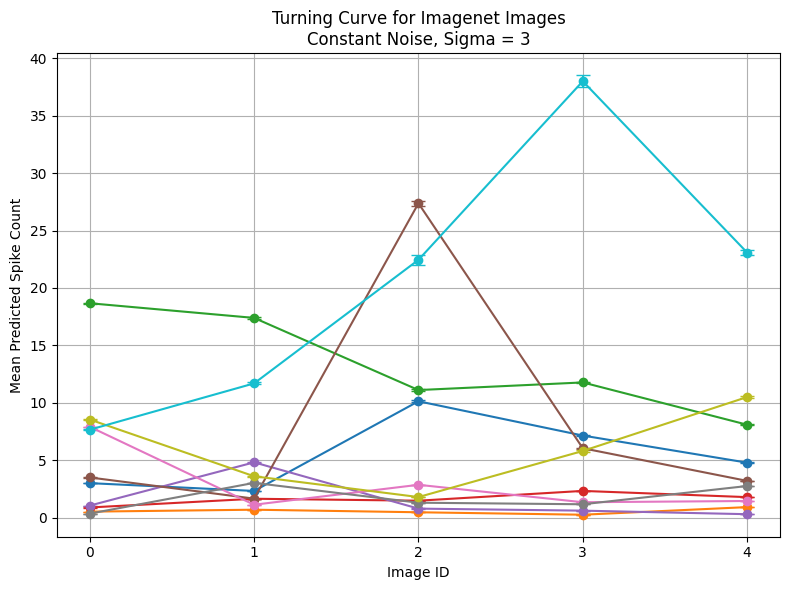

In [16]:
turning_curve(c3_sum, "Constant Noise, Sigma = 3", neurons[:10])

no noise for turning curve

In [7]:
no_noise_sum, no_noise_mean, no_noise_var = predict_loop('no noise', image_stack, 0, [[4,7]])

In [8]:
np.save('saved_inputs_outputs//predictions_july18//no_noise_sum', no_noise_sum)
np.save('saved_inputs_outputs//predictions_july18//no_noise_mean', no_noise_mean)
np.save('saved_inputs_outputs//predictions_july18//no_noise_var', no_noise_var)

In [ ]:
def five_turning_curves(arrays, titles, ten_neurons):
    fig, axes = plt.subplots(5, 1, figsize=(4, 20), sharex=True)

    image_ids = np.array([i for i in range(5)], dtype=int)

    for ax, array, title in zip(axes, arrays, titles):
        mean_array = np.mean(array, axis=1) 
        variance = np.var(array, axis=1)
        std_dev = np.sqrt(variance)

        for neuron in ten_neurons:
            neuron_predictions = mean_array[:, neuron, 0]
            ax.errorbar(image_ids, neuron_predictions, yerr=std_dev[:, neuron, 0],
                        marker='o', linestyle='-', capsize=5)

        ax.set_title(f"{title}", fontsize=10)
        ax.set_ylabel("Mean Predicted Spike Count")
        ax.xaxis.set_major_locator(MultipleLocator(1))
        ax.grid(True)
    plt.xlabel('Image ID')
    plt.tight_layout()
    plt.show()

#### Turning Curves, Dynamic

In [35]:
d_five_arrays = [no_noise_sum, d3_sum, d15_sum, d30_sum, dbin_sum]
d_titles = ['No Noise', 'Dynamic Noise, Sigma = 3', 'Dynamic Noise, Sigma = 15', 
          'Dynamic Noise, Sigma = 30', 'Dynamic\nStochastic Binarization']

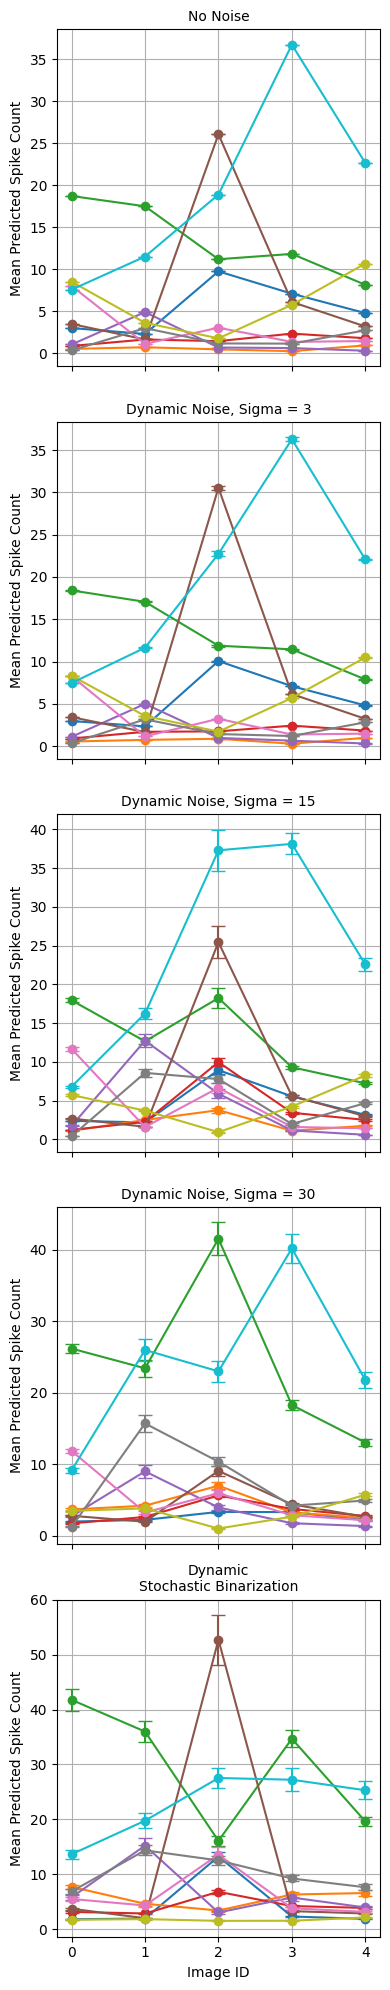

In [36]:
five_turning_curves(d_five_arrays, d_titles, neurons[:10])

#### turning curves, constant

In [42]:
c_five_arrays = [no_noise_sum, c3_sum, c15_sum, c30_sum, cbin_sum]
c_titles = ['No Noise', 'Constant Noise, Sigma = 3', 'Constant Noise, Sigma = 15', 
          'Constant Noise, Sigma = 30', 'Constant\nStochastic Binarization']

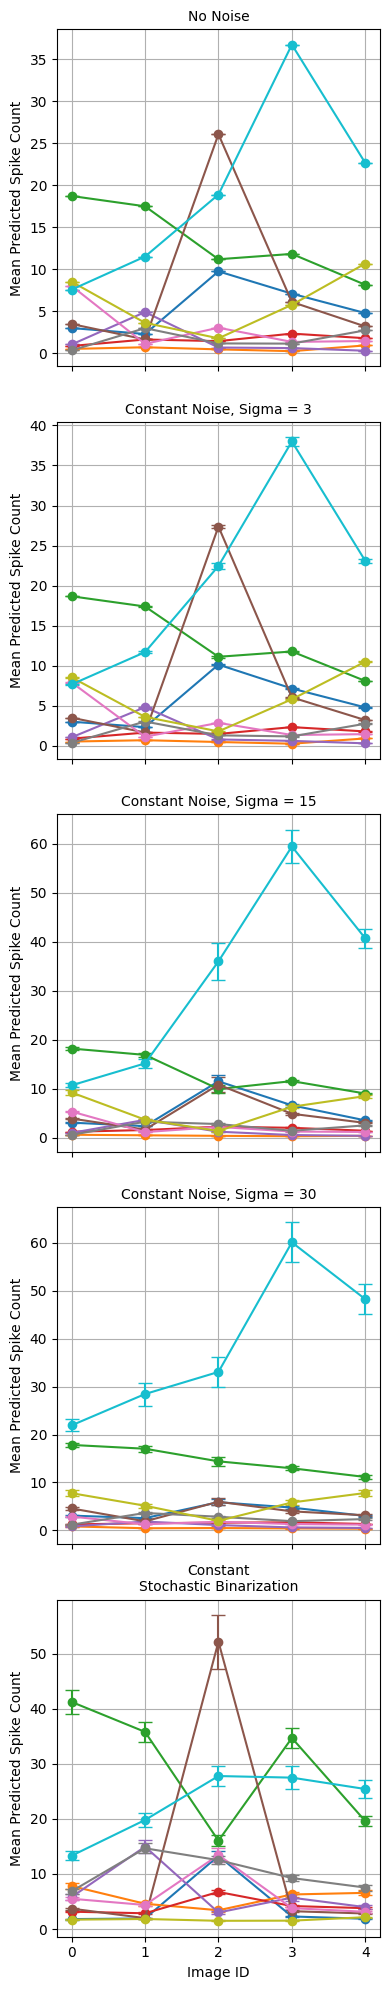

In [43]:
five_turning_curves(c_five_arrays, c_titles, neurons[:10])

#### var-mean scatter plot

In [8]:
c30_sum.shape

(5, 100, 7493, 2)

In [7]:
print(f'c30mean shape: {c30_mean.shape}, c30var shape: {c30_var.shape}\n'
      '(without region label dimension)')

c30mean shape: (5, 7493, 2), c30var shape: (5, 7493, 2)
(without region label dimension)


In [38]:
d30_mean[:, 1234, 0]

array([11.06826682, 14.90954059,  6.25538679, 15.0139551 , 15.78386292])

In [15]:
dynamic_arrays = [[d3_mean, d3_var], [d15_mean, d15_var], [d30_mean, d30_var], [dbin_mean, dbin_var]]
titles = ['Dynamic Noise\nSigma=3', 'Dynamic Noise\nSigma=15', 'Dynamic Noise\nSigma=30', 'Dynamic Noise\nStochastic Binarization']

In [65]:
d3_mean.shape

(5, 7493, 2)

In [ ]:
def mean_var_scatter(mean_array, var_array, title):
    plt.figure(figsize = (6,4))
    cmap = plt.get_cmap('viridis')
    colors = cmap(np.linspace(0, 1, d3_mean.shape[1]))

    for neuron in range(d3_mean.shape[1]): 
        plt.scatter(mean_array[:, neuron, 0], var_array[:, neuron, 0],  marker = '^', color = colors[neuron])

    x = mean_array[:, :, 0].flatten()
    y = var_array[:, :, 0].flatten()

    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    x_fit = np.linspace(np.min(x), np.max(x), 100)
    y_fit = intercept + slope * x_fit
    plt.plot(x_fit, y_fit, color='red', label='Regression line', linewidth=2)

    se_fit = std_err * np.sqrt(1/len(x) + (x_fit - np.mean(x))**2 / np.sum((x - np.mean(x))**2))
    plt.fill_between(x_fit, y_fit - 1.96 * se_fit, y_fit + 1.96 * se_fit, color='gray', alpha=0.3, label='95% CI')

    plt.text(np.min(x), np.max(y), f"Slope: {slope:.3f}\n95% CI: [{slope - 1.96*std_err:.3f}, {slope + 1.96*std_err:.3f}]", fontsize=8, verticalalignment='top')

    plt.title(f'{title}')
    plt.grid(True)    
    plt.tight_layout()
    plt.xlabel('Mean Predicted Spike Count')
    plt.ylabel('Variance in Predicted Spike Count')
    plt.show()


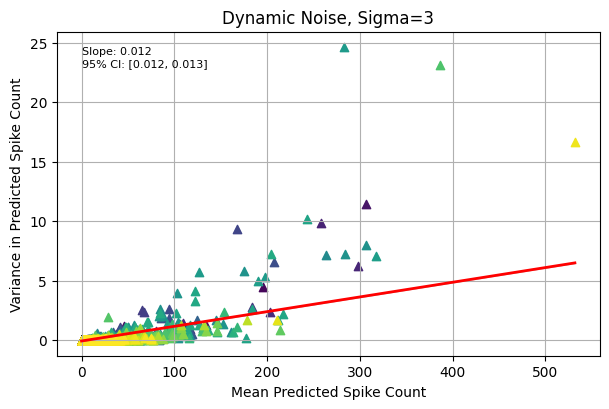

In [70]:
mean_var_scatter(d3_mean, d3_var, 'Dynamic Noise, Sigma=3')

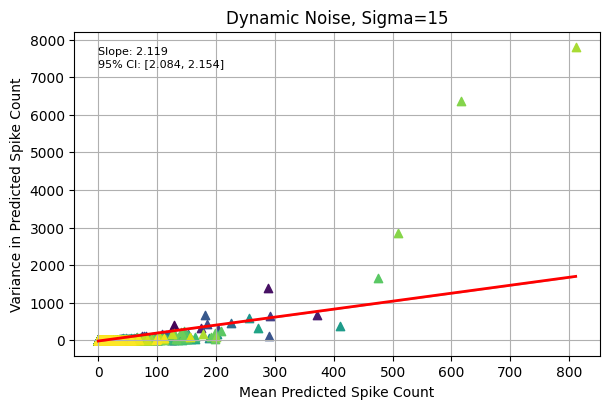

In [71]:
mean_var_scatter(d15_mean, d15_var, 'Dynamic Noise, Sigma=15')

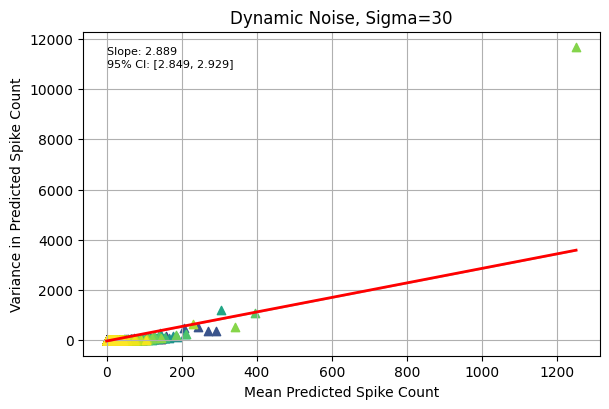

In [72]:
mean_var_scatter(d30_mean, d30_var, 'Dynamic Noise, Sigma=30')

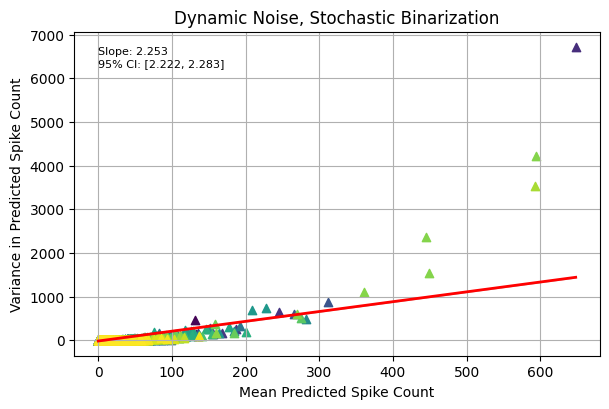

In [73]:
mean_var_scatter(dbin_mean, dbin_var, 'Dynamic Noise, Stochastic Binarization')

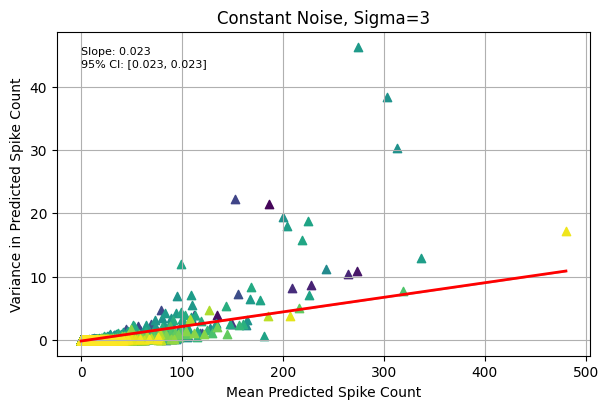

In [75]:
mean_var_scatter(c3_mean, c3_var, 'Constant Noise, Sigma=3')

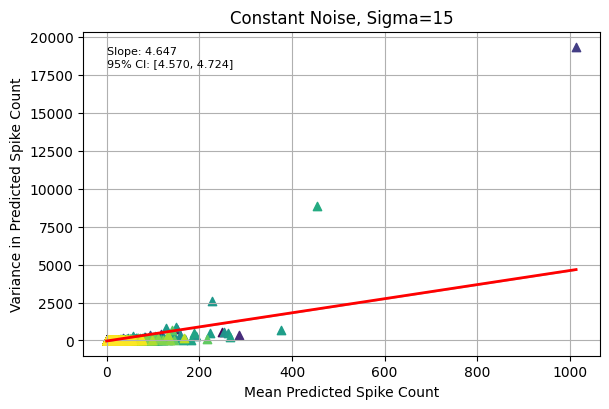

In [76]:
mean_var_scatter(c15_mean, c15_var, 'Constant Noise, Sigma=15')

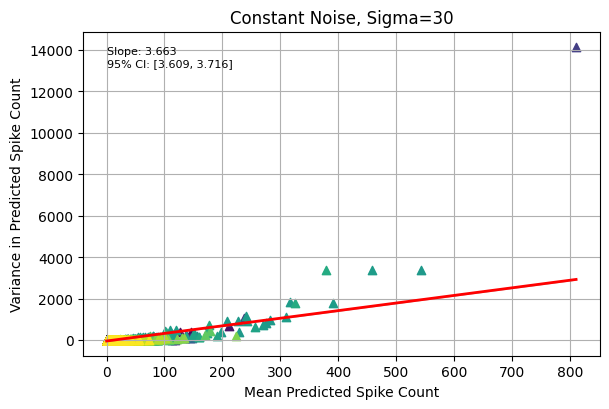

In [77]:
mean_var_scatter(c30_mean, c30_var, 'Constant Noise, Sigma=30')

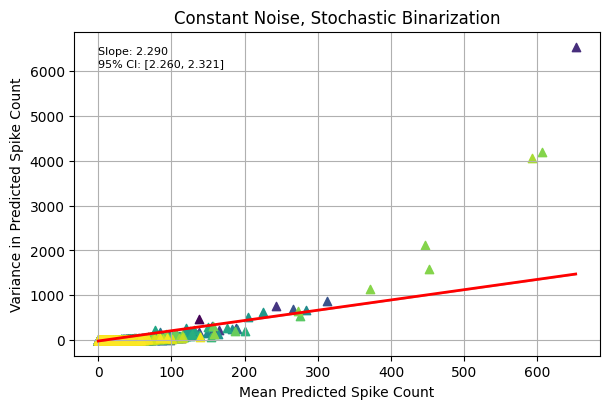

In [78]:
mean_var_scatter(cbin_mean, cbin_var, 'Constant Noise, Stochastic Binarization')